# 15 — 2mu2e MC and Data ABCD closure

Focused validation of the 2mu2e ABCD method. The presentation order is intentional:

1. inspect B/C/D yields and the $B \times C / D$ prediction without A;
2. inspect nominal closure;
3. test one-axis and two-dimensional threshold stability.

MC closure is shown in SR and VR-invDisplaced. Data closure is shown only in VR-invDisplaced. Data SR A is never accessed. Threshold scans use only isolation cuts $\geq 0.25$ (no tighter than the nominal working point). For the current presentation, $(0.25, 0.25)$ is declared as the working-point choice; the final choice may also depend on factors outside this closure study.

In [1]:
import gc
import sys
from pathlib import Path

search_roots = [Path.cwd(), *Path.cwd().parents]
SIDM_DIR = next((path for path in search_roots if path.name == "sidm"), None)
assert SIDM_DIR is not None, "Could not locate the sidm repository root"
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(1, str(SIDM_DIR.parent))

import coffea.util
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

%matplotlib inline


## 1. Inputs and analysis scope

In [2]:
STUDY_DIR = Path.cwd()
if not (STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1").is_dir():
    STUDY_DIR = Path("studies/ABCD_Study")
assert STUDY_DIR.is_dir(), "Run from the repository root or studies/ABCD_Study"
BKG_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1"
DATA_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_data_merged_samples_v1"
HIST_NAME = "mulj_egmlj_iso"
TOPOLOGY = "2mu2e"
NOMINAL_CUTS = (0.25, 0.25)
SCAN_VALUES = np.array([0.25, 0.30, 0.40, 0.50])
X_LABEL = "Mu-LJ Isolation"
Y_LABEL = "EGM-LJ Isolation"
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]

CHANNELS = {
    "SR": "test_SR_2mu2e_spread_cosAlpha_mu_veto",
    "VR-invDisplaced": "test_VR_2mu2e_invDisplaced_spread_cosAlpha_mu_veto",
}

assert np.all(SCAN_VALUES >= NOMINAL_CUTS[0])
assert set(CHANNELS) == {"SR", "VR-invDisplaced"}

def classify_sample(sample):
    if sample.startswith("DoubleMuon"): return "Data"
    if sample.startswith("QCD_"): return "QCD"
    if sample.startswith("DYJetsTo"): return "DY"
    if sample.startswith("TTJets"): return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}: return "Diboson"
    return "Other"

samples_bkg = sorted(path.stem for path in BKG_INPUT_DIR.glob("*.coffea"))
samples_data = sorted(path.stem for path in DATA_INPUT_DIR.glob("*.coffea"))
assert samples_bkg, f"No background files found in {BKG_INPUT_DIR}"
assert samples_data, f"No data files found in {DATA_INPUT_DIR}"
print(f"Background files: {len(samples_bkg)}; Data files: {len(samples_data)}")


Background files: 18; Data files: 68


In [3]:
outputs = {}
for input_dir, samples in [(BKG_INPUT_DIR, samples_bkg), (DATA_INPUT_DIR, samples_data)]:
    for sample in samples:
        try:
            loaded = coffea.util.load(input_dir / f"{sample}.coffea")
            payload = loaded.get("out", loaded)[sample]
            outputs[sample] = payload["hists"][HIST_NAME]
        except Exception as error:
            print(f"**** Failed to load {sample}: {error}")
            outputs.pop(sample, None)
        finally:
            loaded = payload = None
            gc.collect()

sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)
sample_groups["BKG total"] = sum(
    (sample_groups.get(group, []) for group in BACKGROUND_ORDER), []
)

for sample, hist in outputs.items():
    available = set(hist.axes["channel"])
    missing = set(CHANNELS.values()) - available
    assert not missing, f"{sample}/{HIST_NAME} missing channels: {sorted(missing)}"

print({group: len(samples) for group, samples in sample_groups.items()})


{'DY': 2, 'QCD': 12, 'TTJets': 1, 'Diboson': 3, 'Data': 68, 'BKG total': 18}


## 2. ABCD helpers

In [4]:
def sample_hist(sample, selection):
    return outputs[sample][{"channel": CHANNELS[selection]}]

def group_hist(group, selection):
    members = [group] if group in outputs else sample_groups.get(group, [])
    hists = [sample_hist(sample, selection) for sample in members]
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total

def values_variances(h2d):
    # Fold overflow into the last visible isolation-fail bin; exclude underflow.
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    variances = (np.clip(values, 0, None) if variances is None
                 else np.asarray(variances, dtype=float).copy())
    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values, variances = values[:-1, :], variances[:-1, :]
    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values, variances = values[:, :-1], variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]

def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {
        "A": (x < xcut) & (y < ycut),
        "B": (x >= xcut) & (y < ycut),
        "C": (x < xcut) & (y >= ycut),
        "D": (x >= xcut) & (y >= ycut),
    }

def region_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        error = np.sqrt(variance)
        result[region] = {
            "yield": value, "error": error,
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result

def prediction(stats):
    b, c, d = (stats[region]["yield"] for region in "BCD")
    eb, ec, ed = (stats[region]["error"] for region in "BCD")
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        return np.nan, np.nan
    pred = b * c / d
    terms = [(eb / b)**2 if b else 0, (ec / c)**2 if c else 0, (ed / d)**2]
    return pred, abs(pred) * np.sqrt(sum(terms))

def closure_row(h2d, cuts):
    stats = region_stats(h2d, cuts)
    pred, pred_err = prediction(stats)
    obs, obs_err = stats["A"]["yield"], stats["A"]["error"]
    kappa = obs / pred if pred > 0 else np.nan
    kappa_err = (abs(kappa) * np.sqrt((obs_err / obs)**2 + (pred_err / pred)**2)
                 if obs > 0 and pred > 0 else np.nan)
    pull_denominator = np.sqrt(obs_err**2 + pred_err**2)
    pull = (obs - pred) / pull_denominator if pull_denominator > 0 else np.nan
    row = {"xcut": cuts[0], "ycut": cuts[1],
           "A_pred": pred, "A_pred_err": pred_err,
           "kappa": kappa, "kappa_err": kappa_err, "pull": pull}
    for region in "ABCD":
        for field in ("yield", "error", "neff"):
            row[f"{region}_{field}"] = stats[region][field]
    finite_neff = [stats[r]["neff"] for r in "ABCD" if np.isfinite(stats[r]["neff"])]
    row["min_neff"] = min(finite_neff) if finite_neff else np.nan
    row["relative_pred_err"] = pred_err / pred if pred > 0 else np.nan
    row["min_control_yield"] = min(stats[r]["yield"] for r in "BCD")
    return row


## 3. B/C/D yields and prediction before closure

This table intentionally excludes the observed A yield, $\kappa$, and pull.

In [5]:
TARGETS = (
    ("SR", "BKG total", "MC SR"),
    ("VR-invDisplaced", "BKG total", "MC VR"),
    ("VR-invDisplaced", "Data", "Data VR"),
)
assert not any(selection == "SR" and group == "Data" for selection, group, _ in TARGETS)

nominal_rows = []
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    assert hist is not None, f"Missing histogram for {label}"
    nominal_rows.append({"sample": label, **closure_row(hist, NOMINAL_CUTS)})
nominal_summary = pd.DataFrame(nominal_rows)

control_columns = [
    "sample", "B_yield", "B_error", "C_yield", "C_error",
    "D_yield", "D_error", "A_pred", "A_pred_err",
]
display(nominal_summary[control_columns])


,sample,B_yield,B_error,C_yield,C_error,D_yield,D_error,A_pred,A_pred_err
0,MC SR,36.868713,11.275693,12.143459,8.080562,228.191738,138.441819,1.962007,1.865866
1,MC VR,1431.711980,208.852501,1574.024265,572.361765,3761.566297,383.899652,599.098679,242.558931
2,Data VR,1245.000000,35.284558,1690.000000,41.109610,3692.000000,60.761830,569.894366,23.259684


## 4. Nominal closure

Only after the control yields and prediction have been inspected, compare the observed and predicted A yields.

,sample,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull
0,MC SR,31.003767,13.552784,1.962007,1.865866,15.802071,16.539297,2.122839
1,MC VR,522.082398,184.791147,599.098679,242.558931,0.871446,0.468643,-0.252570
2,Data VR,551.000000,23.473389,569.894366,23.259684,0.966846,0.057041,-0.571766


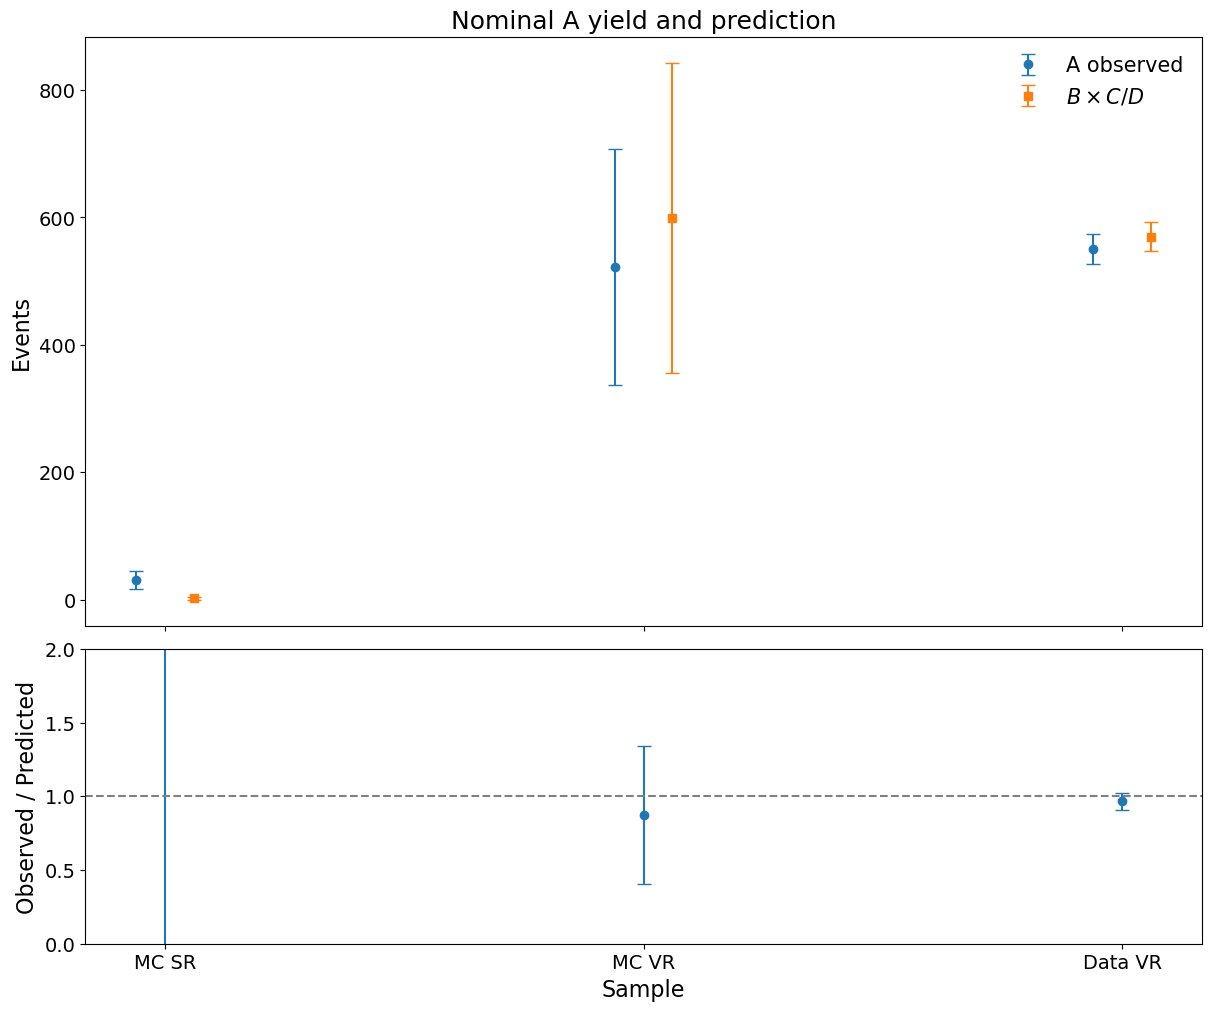

In [6]:
closure_columns = [
    "sample", "A_yield", "A_error", "A_pred", "A_pred_err",
    "kappa", "kappa_err", "pull",
]
display(nominal_summary[closure_columns])

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)
positions = np.arange(len(nominal_summary))
axes[0].errorbar(positions - 0.06, nominal_summary.A_yield,
                 yerr=nominal_summary.A_error, fmt="o", capsize=5,
                 label="A observed")
axes[0].errorbar(positions + 0.06, nominal_summary.A_pred,
                 yerr=nominal_summary.A_pred_err, fmt="s", capsize=5,
                 label=r"$B \times C / D$")
axes[0].set(ylabel="Events", title="Nominal A yield and prediction")
axes[0].legend(frameon=False, fontsize=15)
axes[1].errorbar(positions, nominal_summary.kappa, yerr=nominal_summary.kappa_err,
                 fmt="o", capsize=5)
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set(ylabel="Observed / Predicted", xlabel="Sample", ylim=(0, 2))
axes[1].set_xticks(positions, nominal_summary["sample"])
for ax in axes:
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16); ax.yaxis.label.set_size(16)
    ax.title.set_size(18)


## 5. One-axis threshold scans

One isolation threshold is fixed at 0.25 while the other is scanned over 0.25, 0.30, 0.40, and 0.50. All scan points are correlated cumulative selections.

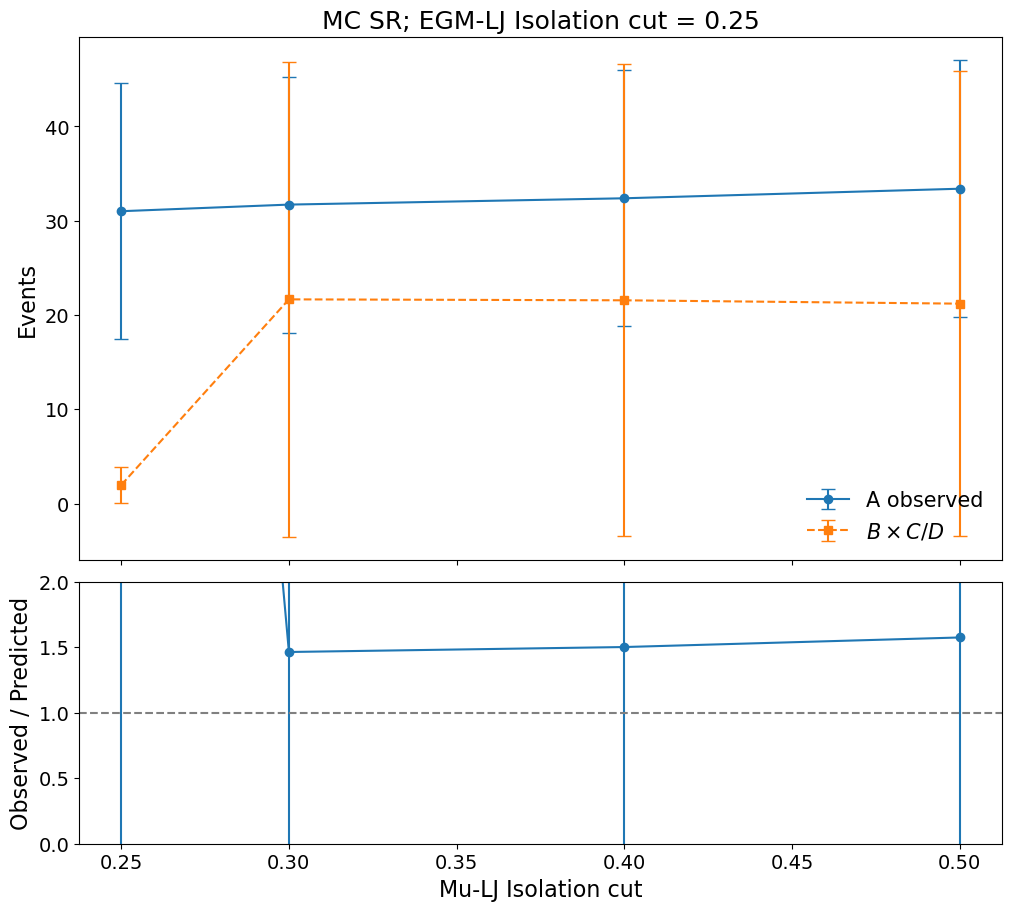

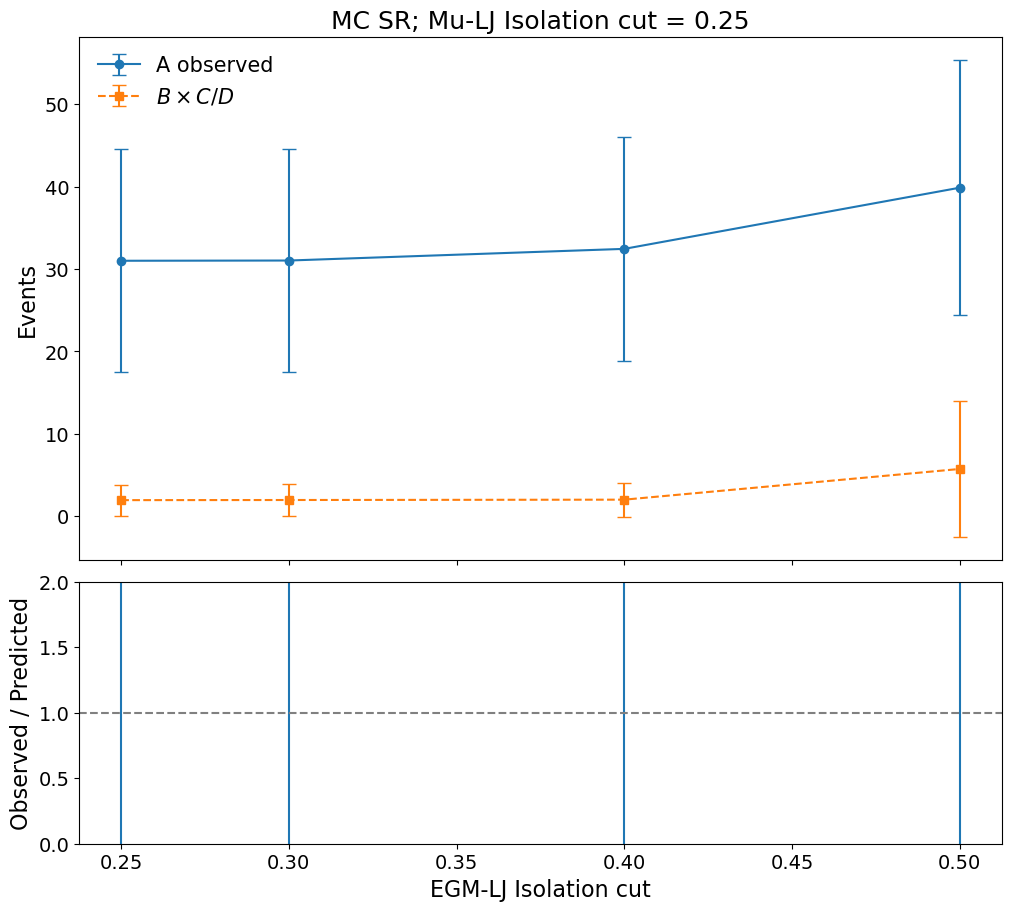

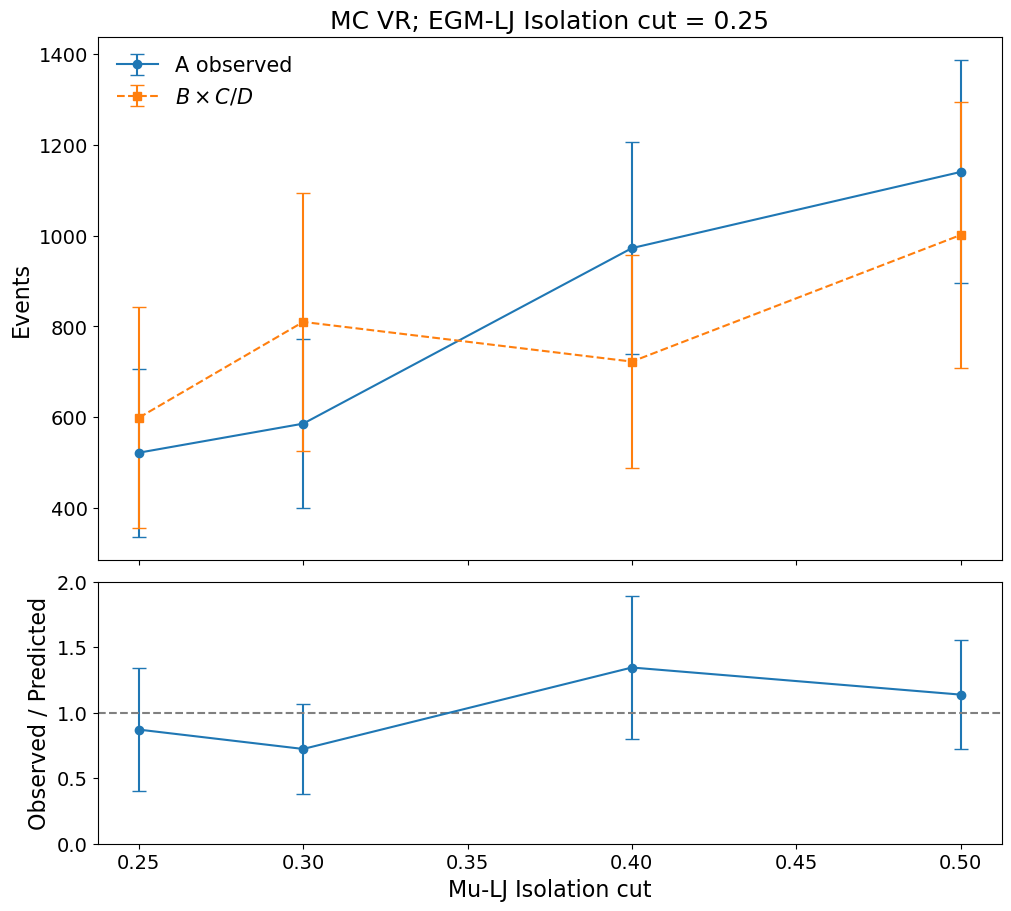

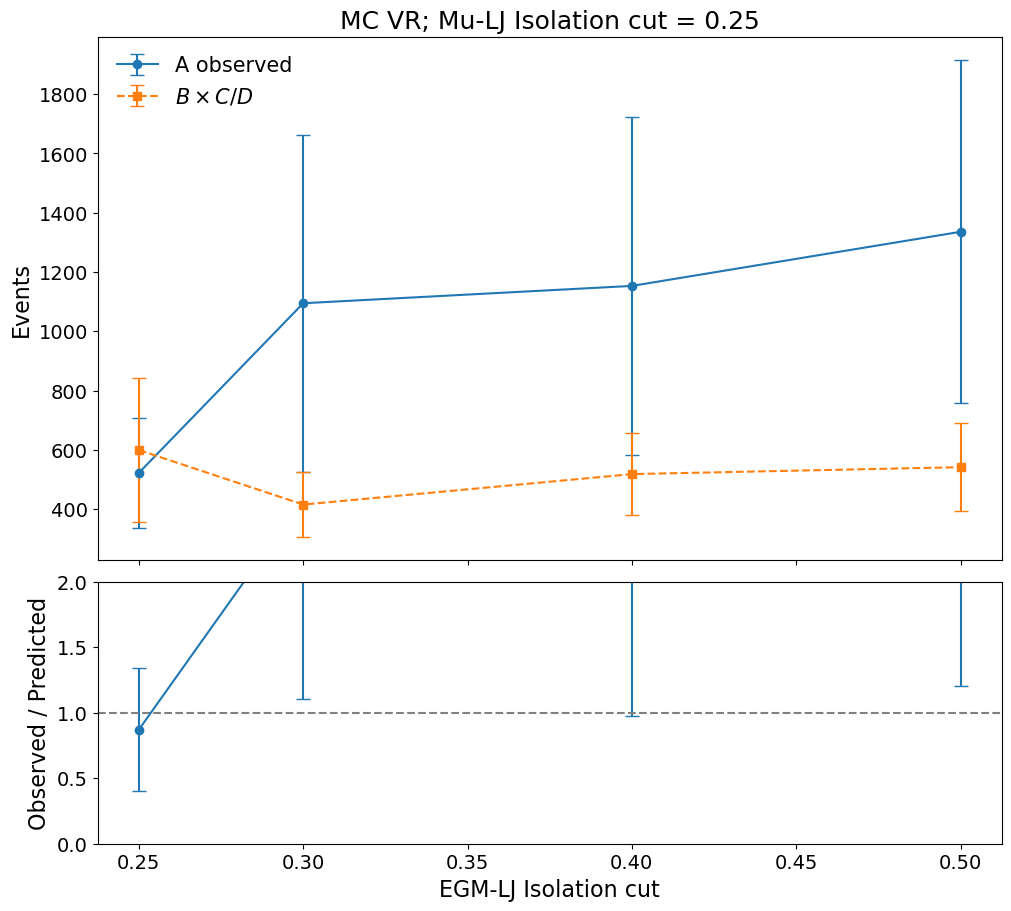

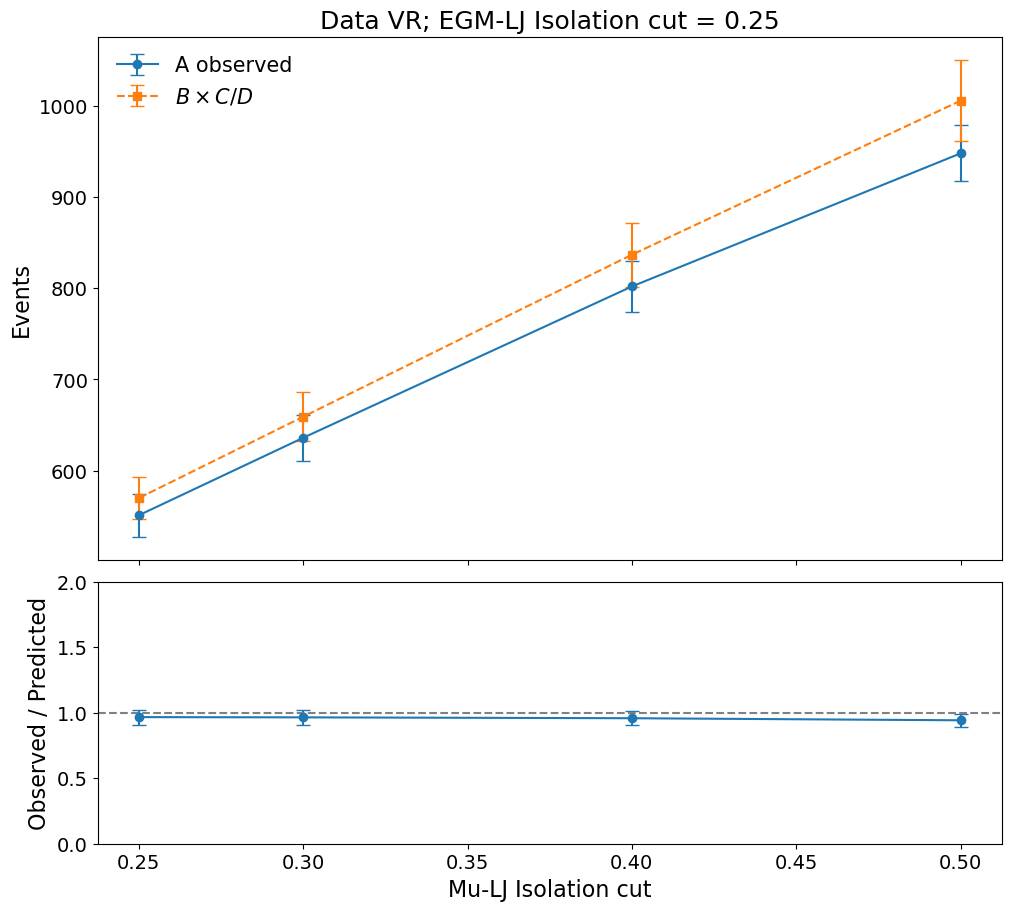

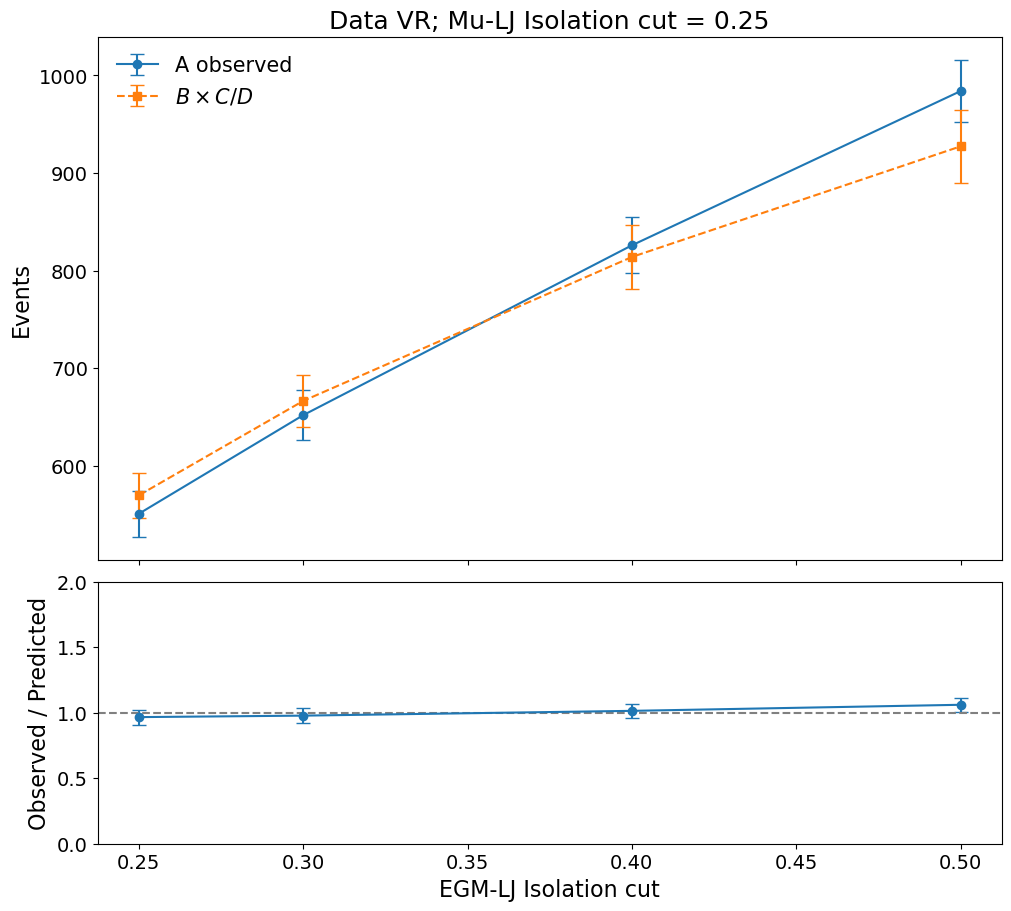

In [7]:
def scan_one_axis(h2d, scan_axis):
    rows = []
    for scan_cut in SCAN_VALUES:
        cuts = ((scan_cut, NOMINAL_CUTS[1]) if scan_axis == "x"
                else (NOMINAL_CUTS[0], scan_cut))
        rows.append(closure_row(h2d, cuts))
    return pd.DataFrame(rows)

def plot_one_axis_scan(frame, scan_label, fixed_label, title):
    fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]},
                             constrained_layout=True)
    axes[0].errorbar(frame["xcut"] if scan_label == X_LABEL else frame["ycut"],
                     frame.A_yield, yerr=frame.A_error, fmt="o-", capsize=5,
                     label="A observed")
    axes[0].errorbar(frame["xcut"] if scan_label == X_LABEL else frame["ycut"],
                     frame.A_pred, yerr=frame.A_pred_err, fmt="s--", capsize=5,
                     label=r"$B \times C/D$")
    axes[0].set(ylabel="Events", title=f"{title}; {fixed_label} cut = 0.25")
    axes[0].legend(frameon=False, fontsize=15)
    scan_coordinate = frame["xcut"] if scan_label == X_LABEL else frame["ycut"]
    axes[1].errorbar(scan_coordinate, frame.kappa, yerr=frame.kappa_err,
                     fmt="o-", capsize=5)
    axes[1].axhline(1, color="gray", linestyle="--")
    axes[1].set(xlabel=f"{scan_label} cut", ylabel="Observed / Predicted", ylim=(0, 2))
    for ax in axes:
        ax.tick_params(axis="both", labelsize=14)
        ax.xaxis.label.set_size(16); ax.yaxis.label.set_size(16)
        ax.title.set_size(18)
    return fig

one_axis_scans = {}
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    for scan_axis, scan_label, fixed_label in [
        ("x", X_LABEL, Y_LABEL), ("y", Y_LABEL, X_LABEL),
    ]:
        frame = scan_one_axis(hist, scan_axis)
        one_axis_scans[(label, scan_axis)] = frame
        plot_one_axis_scan(frame, scan_label, fixed_label, label)
        plt.show(); plt.close()


## 6. Two-dimensional threshold scans

Both thresholds are varied over the allowed grid. Heatmaps show closure, pull, prediction uncertainty, and the minimum effective statistics among A/B/C/D. These grid points are correlated and are treated as robustness checks, not independent tests.

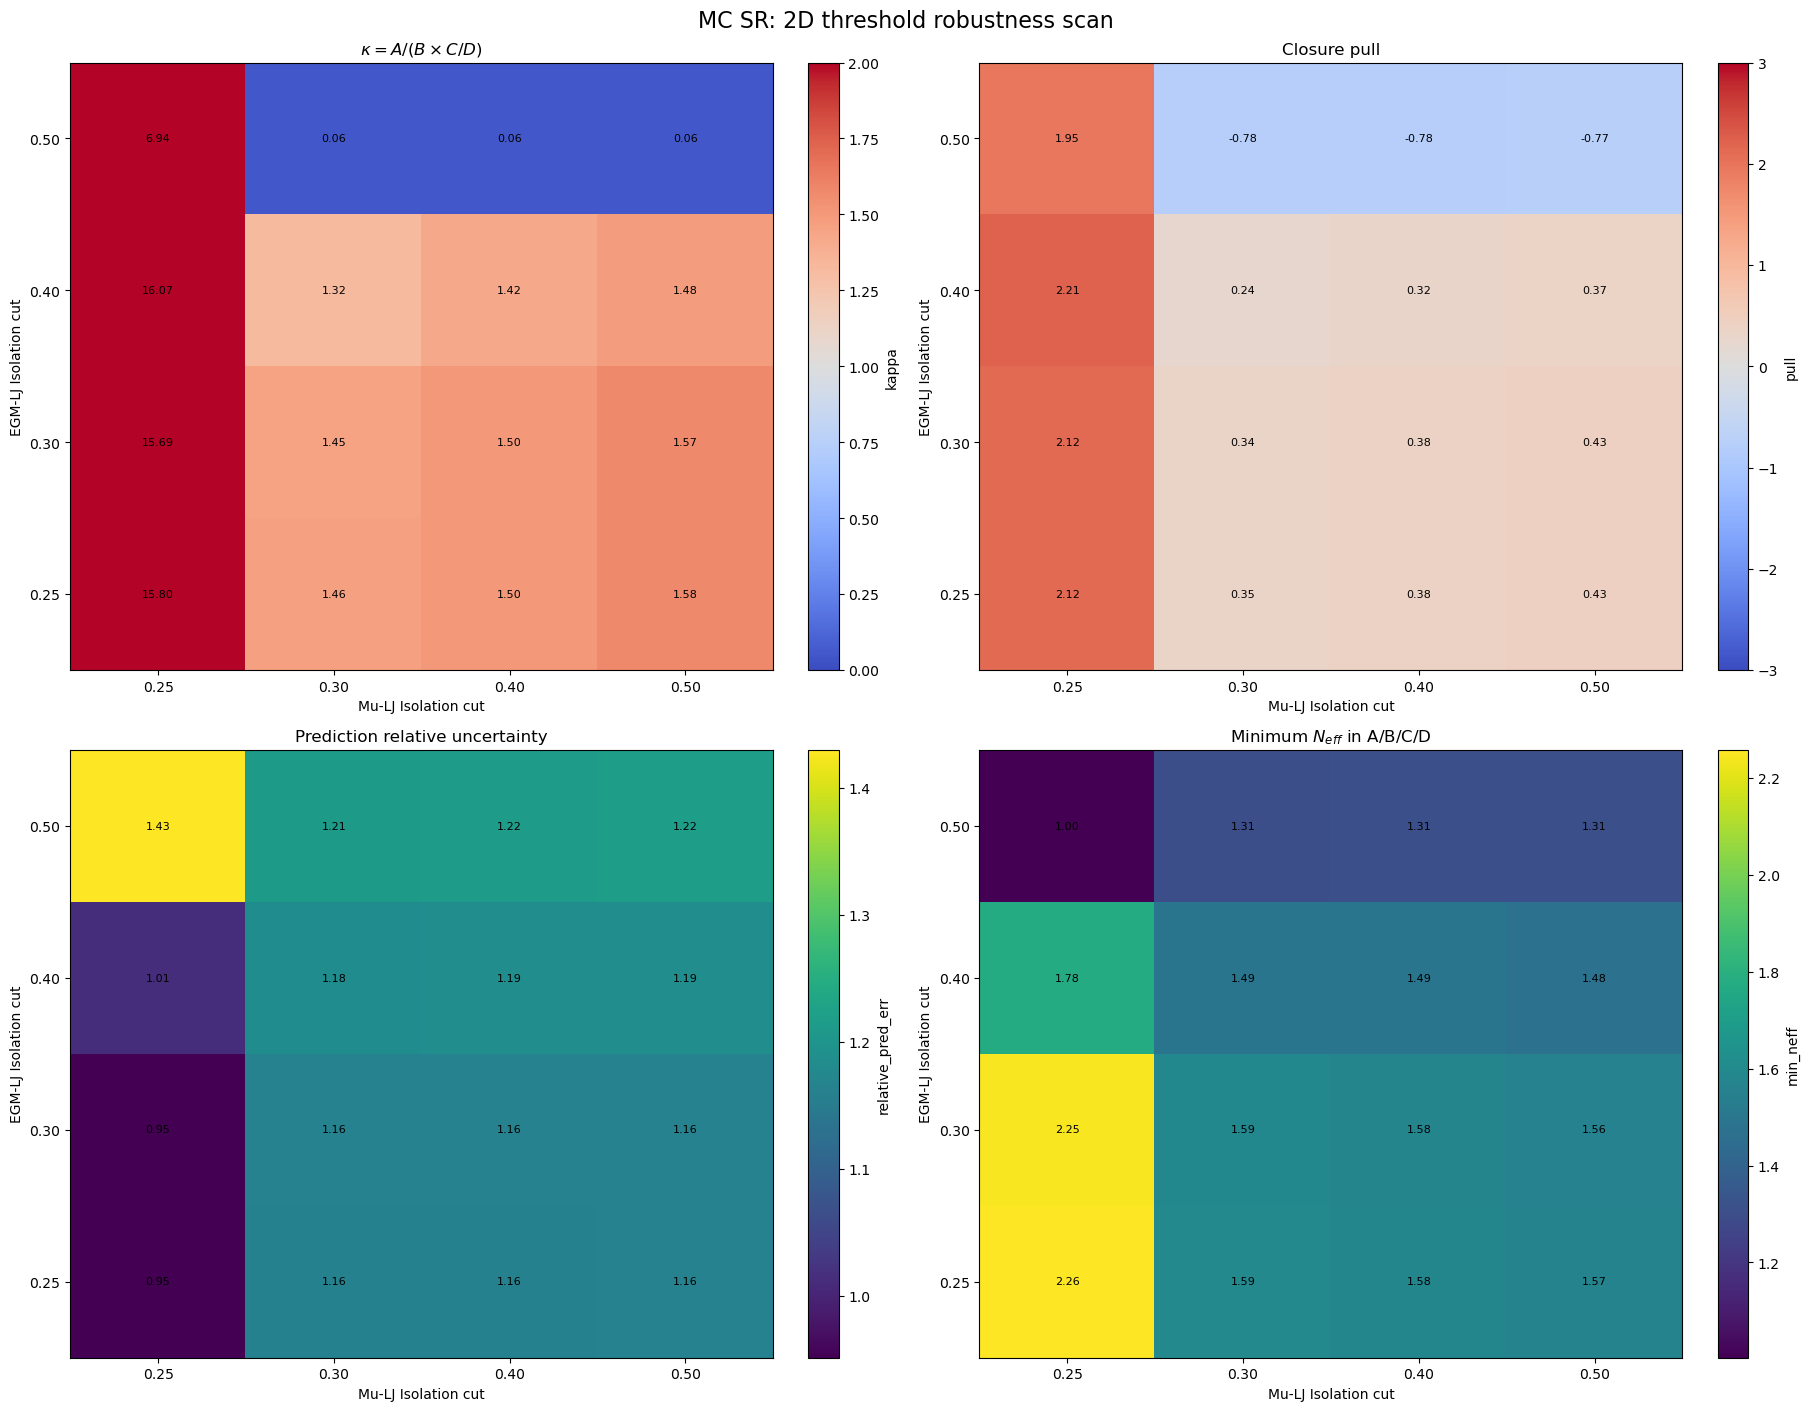

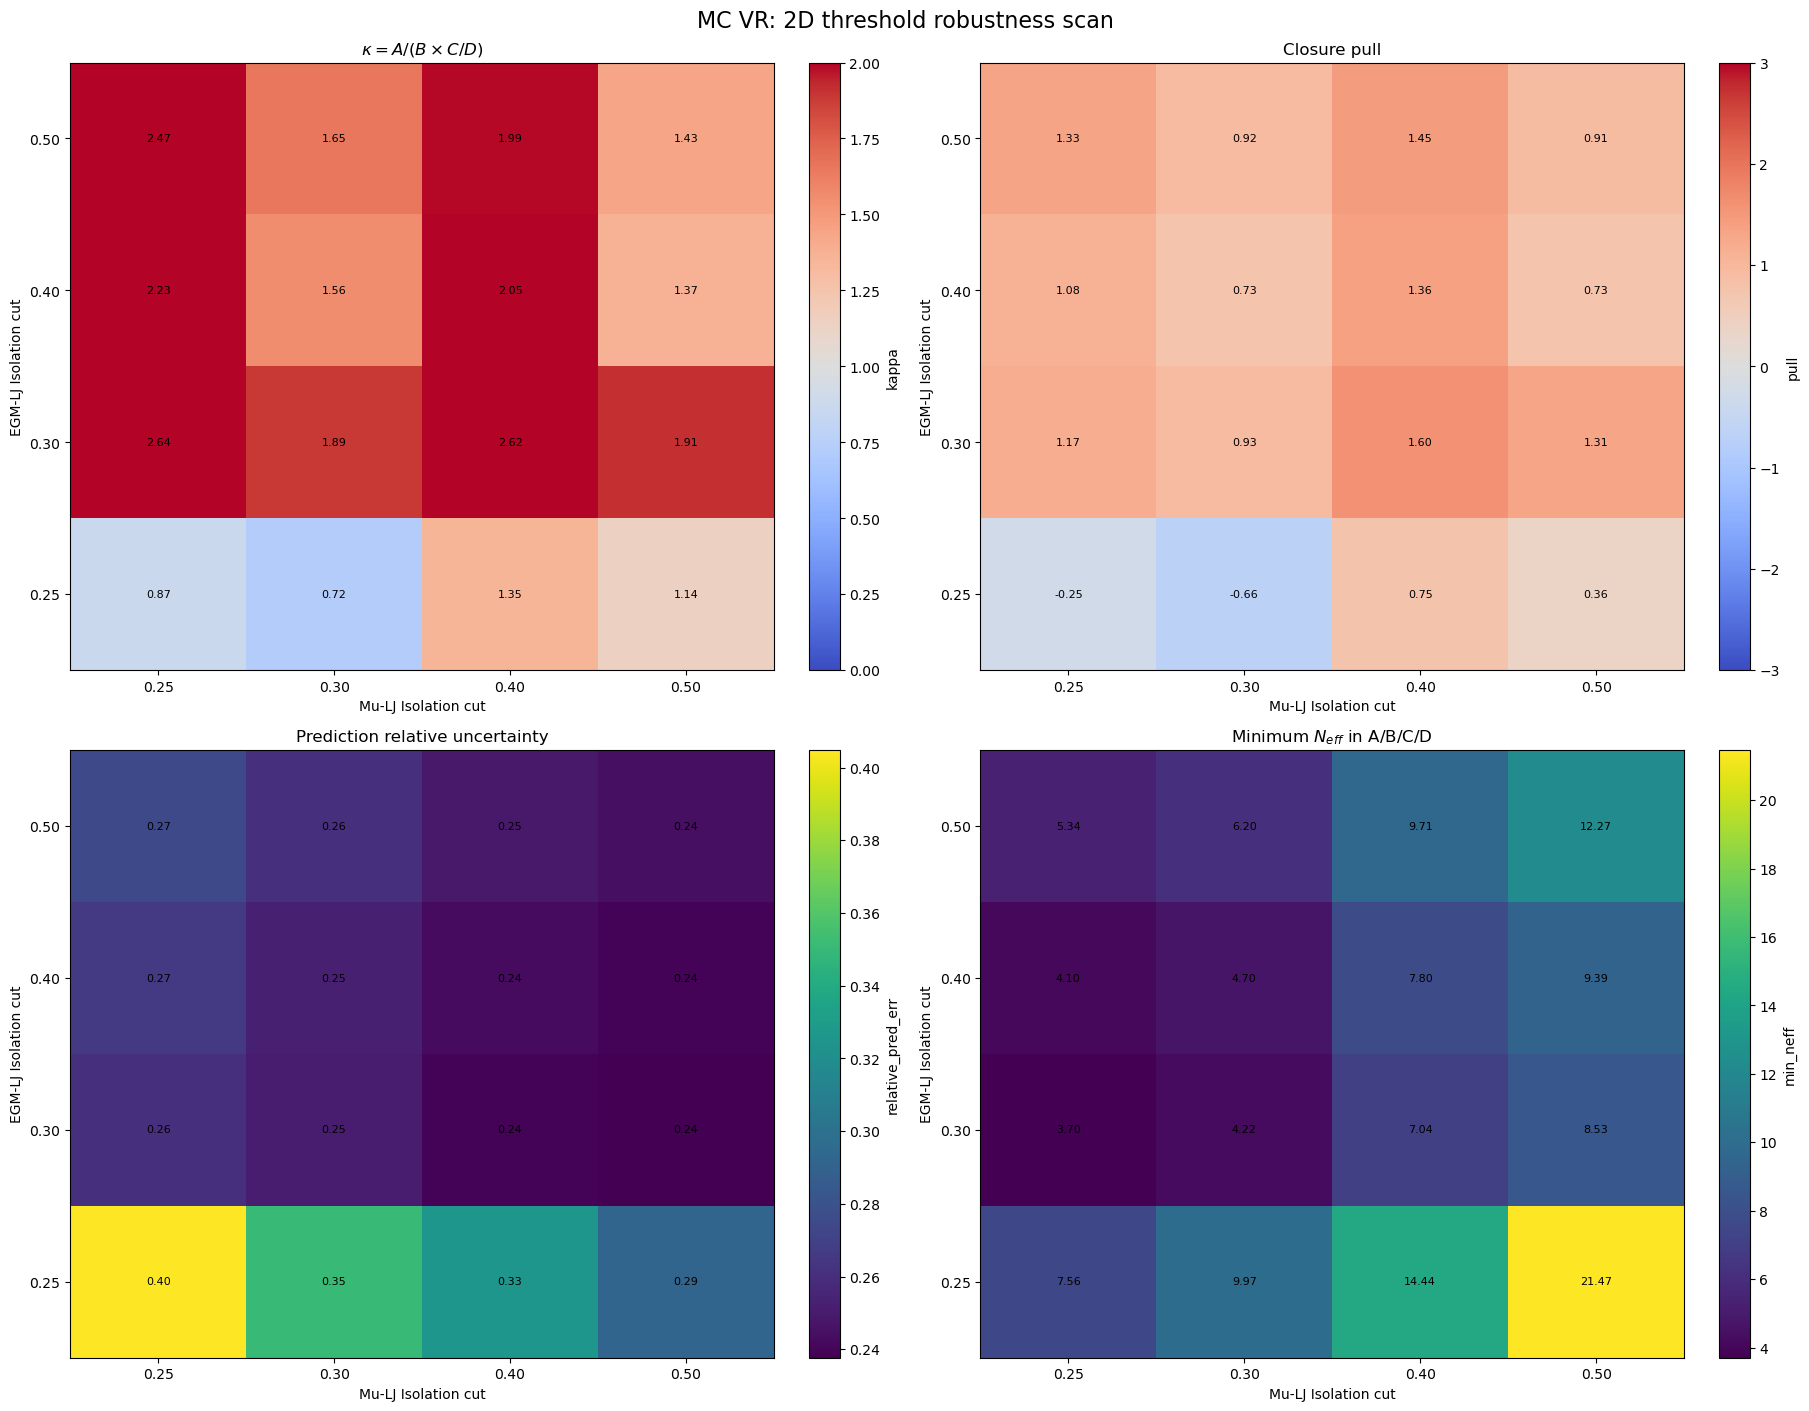

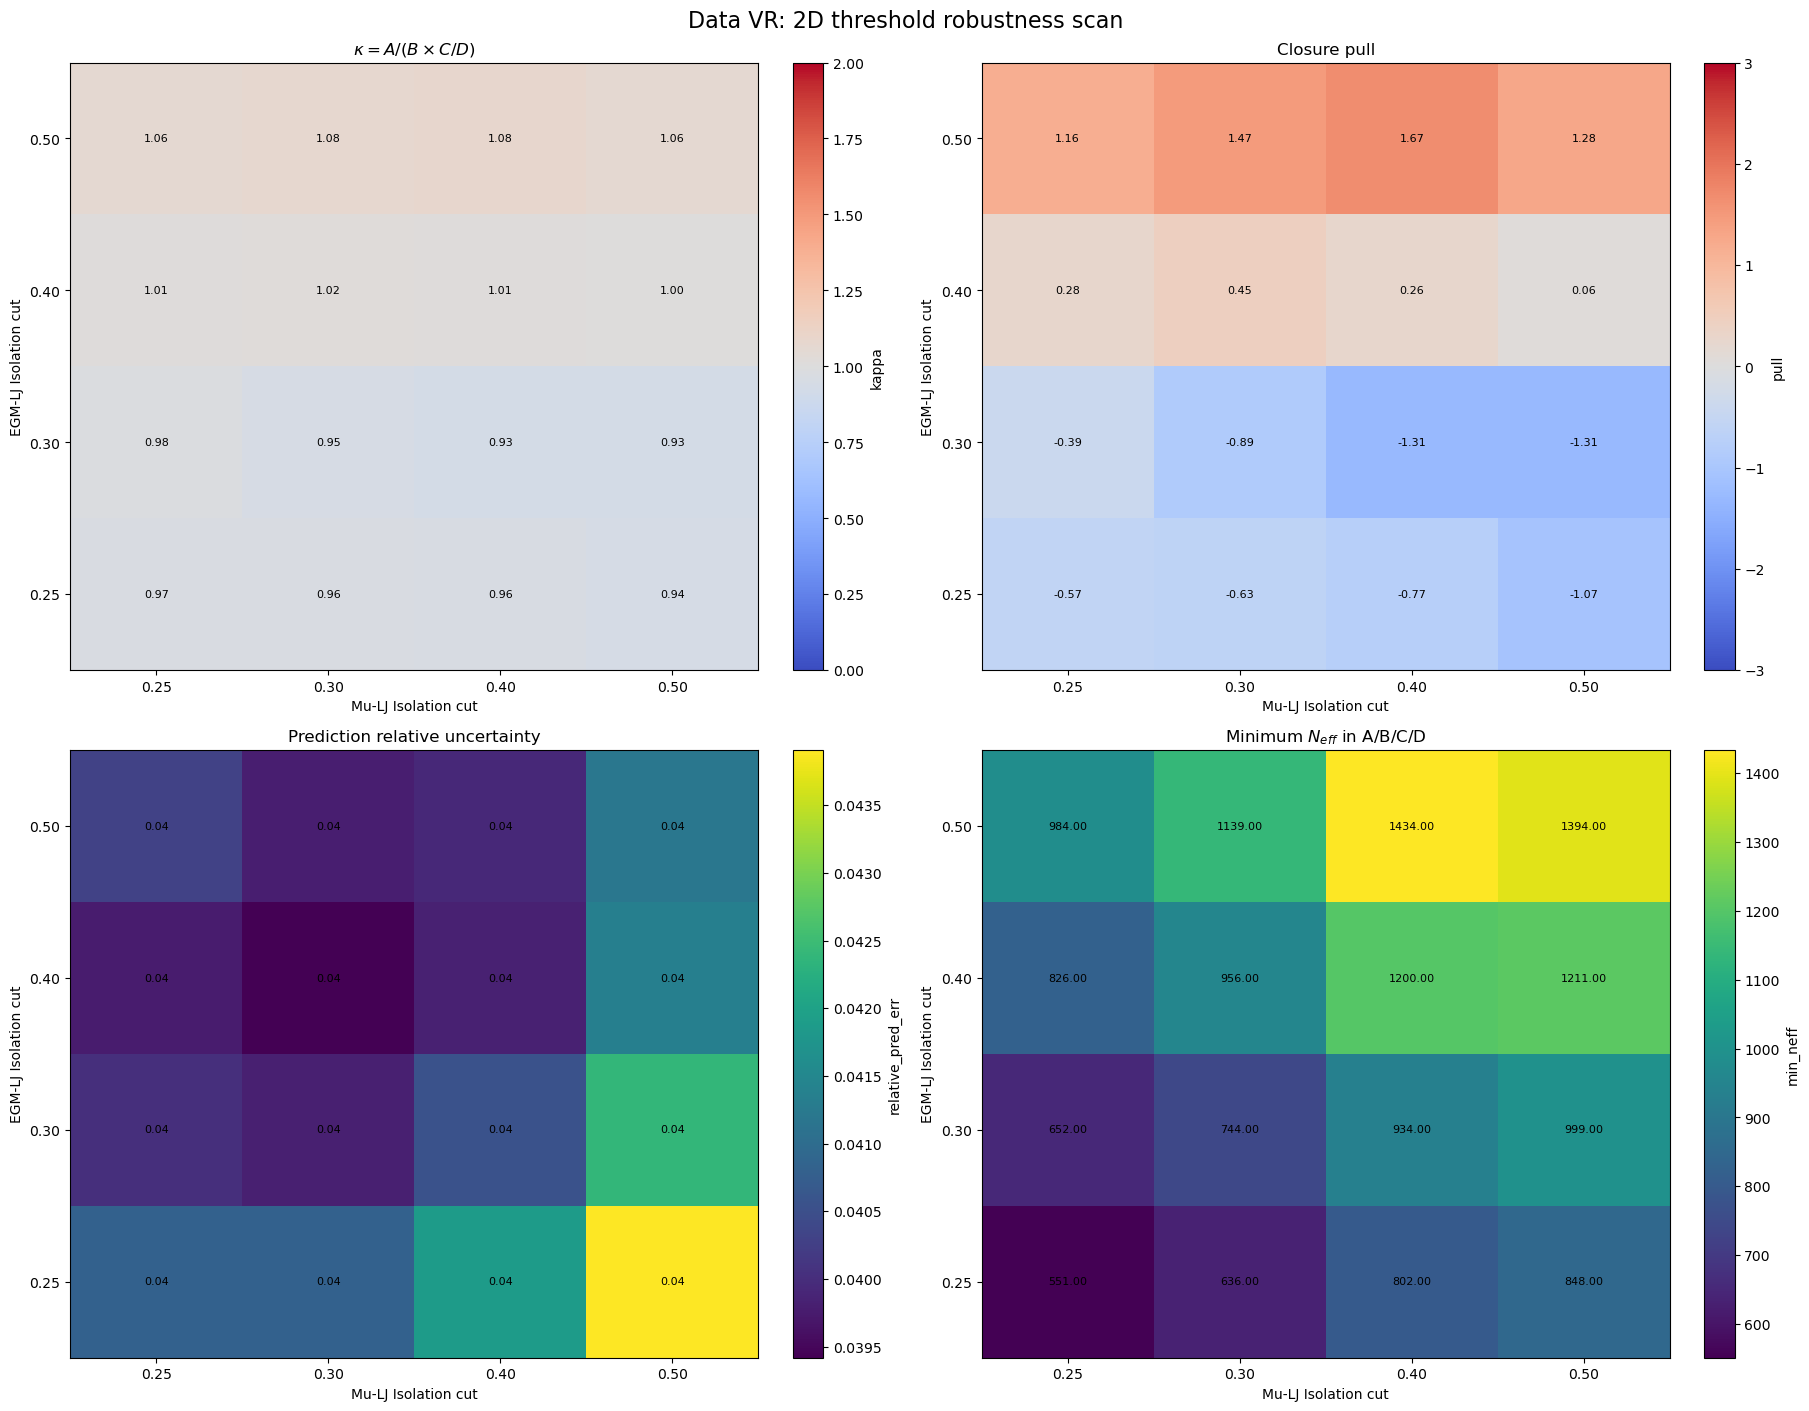

In [8]:
def scan_two_axes(h2d):
    return pd.DataFrame(
        closure_row(h2d, (xcut, ycut))
        for xcut in SCAN_VALUES for ycut in SCAN_VALUES
    )

def draw_heatmap(ax, frame, value, title, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    image = ax.imshow(table.values, origin="lower", aspect="auto",
                      cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel=f"{X_LABEL} cut", ylabel=f"{Y_LABEL} cut", title=title)
    for row_index, ycut in enumerate(table.index):
        for column_index, xcut in enumerate(table.columns):
            value_here = table.loc[ycut, xcut]
            label = f"{value_here:.2f}" if np.isfinite(value_here) else "nan"
            ax.text(column_index, row_index, label, ha="center", va="center", fontsize=8)
    plt.colorbar(image, ax=ax, label=value)

two_axis_scans = {}
for selection, group, label in TARGETS:
    frame = scan_two_axes(group_hist(group, selection))
    two_axis_scans[label] = frame
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
    draw_heatmap(axes[0, 0], frame, "kappa", r"$\kappa=A/(B \times C/D)$",
                 cmap="coolwarm", vmin=0, vmax=2)
    draw_heatmap(axes[0, 1], frame, "pull", "Closure pull",
                 cmap="coolwarm", vmin=-3, vmax=3)
    draw_heatmap(axes[1, 0], frame, "relative_pred_err",
                 "Prediction relative uncertainty")
    draw_heatmap(axes[1, 1], frame, "min_neff", r"Minimum $N_{eff}$ in A/B/C/D")
    fig.suptitle(f"{label}: 2D threshold robustness scan", fontsize=16)
    plt.show(); plt.close(fig)


## 7. Scan tables and MC statistical diagnostics

In [9]:
scan_columns = [
    "xcut", "ycut", "A_yield", "A_error", "A_pred", "A_pred_err",
    "kappa", "kappa_err", "pull", "relative_pred_err", "min_neff",
]
for label, frame in two_axis_scans.items():
    print(label)
    display(frame[scan_columns])

mc_neff_columns = ["sample"] + [f"{region}_neff" for region in "ABCD"]
mc_neff_columns += ["A_error", "A_pred_err", "relative_pred_err"]
display(nominal_summary[nominal_summary["sample"].str.startswith("MC")][mc_neff_columns])


MC SR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,31.003767,13.552784,1.962007,1.865866,15.802071,16.539297,2.122839,0.950999,2.258404
1,0.25,0.30,31.032941,13.552816,1.977844,1.882543,15.690285,16.431257,2.123455,0.951815,2.247595
2,0.25,0.40,32.447346,13.585118,2.019329,2.045684,16.068381,17.613523,2.214835,1.013051,1.777258
3,0.25,0.50,39.868429,15.435563,5.742829,8.211340,6.942298,10.283847,1.951843,1.429842,1.003143
4,0.30,0.25,31.705333,13.568816,21.654452,25.168193,1.464148,1.813425,0.351517,1.162264,1.591882
5,0.30,0.30,31.763682,13.568879,21.866242,25.430887,1.452636,1.799804,0.343371,1.163020,1.589820
6,0.30,0.40,33.178087,13.601143,25.222720,29.852416,1.315405,1.647594,0.242506,1.183553,1.490865
7,0.30,0.50,40.599169,15.449669,736.621313,892.948665,0.055115,0.070027,-0.779348,1.212222,1.306843
8,0.40,0.25,32.375153,13.584798,21.554197,25.043437,1.502035,1.855508,0.379807,1.161882,1.581186
9,0.40,0.30,32.527073,13.585183,21.675906,25.209864,1.500610,1.854386,0.378917,1.163036,1.576749


MC VR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,522.082398,184.791147,599.098679,242.558931,0.871446,0.468643,-0.252570,0.404873,7.562783
1,0.25,0.30,1094.419127,568.792998,415.187515,108.288719,2.635963,1.532800,1.173092,0.260819,3.702191
2,0.25,0.40,1152.914568,569.188421,517.941432,137.797253,2.225955,1.248355,1.084255,0.266048,4.102817
3,0.25,0.50,1335.471314,578.041158,541.333952,148.704468,2.467001,1.264703,1.330520,0.274700,5.337669
4,0.30,0.25,586.043390,185.577076,809.919900,283.917933,0.723582,0.341819,-0.660037,0.350551,9.972657
5,0.30,0.30,1169.106602,569.105418,619.805699,155.126815,1.886247,1.032456,0.931225,0.250283,4.220100
6,0.30,0.40,1235.057442,569.547770,793.421873,199.979081,1.556621,0.818060,0.731626,0.252046,4.702340
7,0.30,0.50,1440.255451,578.534611,871.468166,226.953993,1.652677,0.791175,0.915246,0.260427,6.197555
8,0.40,0.25,972.350822,234.081622,722.602273,235.108419,1.345624,0.544631,0.752780,0.325364,14.438469
9,0.40,0.30,1556.740011,586.717308,593.645350,142.130839,2.622340,1.170889,1.595353,0.239420,7.040028


Data VR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,551.0,23.473389,569.894366,23.259684,0.966846,0.057041,-0.571766,0.040814,551.0
1,0.25,0.30,652.0,25.534291,666.575906,26.681770,0.978133,0.054775,-0.394677,0.040028,652.0
2,0.25,0.40,826.0,28.740216,814.053925,32.362365,1.014675,0.053606,0.276006,0.039755,826.0
3,0.25,0.50,984.0,31.368774,927.374868,37.379453,1.061060,0.054527,1.160404,0.040307,984.0
4,0.30,0.25,636.0,25.219040,659.090909,26.904029,0.964966,0.054915,-0.626180,0.040820,636.0
5,0.30,0.30,744.0,27.276363,780.779535,31.079484,0.952894,0.051567,-0.889440,0.039806,744.0
6,0.30,0.40,956.0,30.919250,934.220624,36.825463,1.023313,0.052177,0.452940,0.039418,956.0
7,0.30,0.50,1139.0,33.749074,1059.459449,42.159292,1.075077,0.053338,1.472871,0.039793,1139.0
8,0.40,0.25,802.0,28.319605,836.837782,35.055130,0.958370,0.052507,-0.773055,0.041890,802.0
9,0.40,0.30,934.0,30.561414,1000.385542,40.565204,0.933640,0.048647,-1.307082,0.040550,934.0


,sample,A_neff,B_neff,C_neff,D_neff,A_error,A_pred_err,relative_pred_err
0,MC SR,5.233255,10.691275,2.258404,2.716847,13.552784,1.865866,0.950999
1,MC VR,7.982075,46.992869,7.562783,96.006802,184.791147,242.558931,0.404873
